In [2]:
!pip install -q nltk textblob shap transformers torch scikit-learn seaborn joblib

In [71]:
import pandas as pd
import numpy as np
import nltk
import shap
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [32]:
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [75]:
from transformers import pipeline

In [7]:
train_df = pd.read_csv("BBC News.csv")
print("Shape:", train_df.shape)
print("Columns:",train_df.columns)


Shape: (1490, 3)
Columns: Index(['ArticleId', 'Text', 'Category'], dtype='object')


In [13]:
train_df.isnull().sum()

,0
ArticleId,0
Text,0
Category,0


In [8]:
train_df.head()

,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business


# EDA and Pre-processing

/tmp/ipykernel_4941/1737776051.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, ax=ax, palette="viridis")


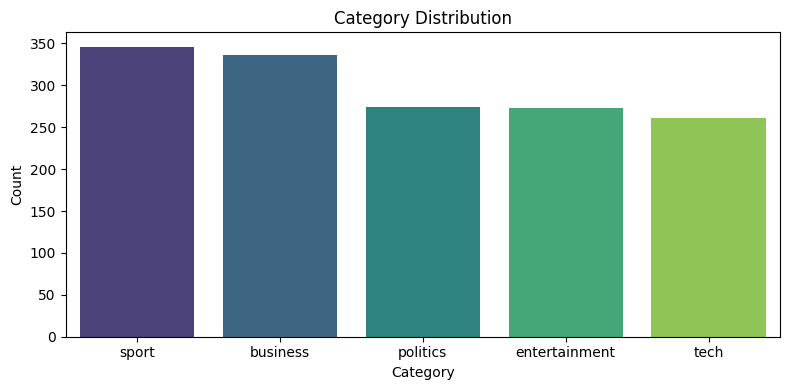

,count
Category,
sport,346
business,336
politics,274
entertainment,273
tech,261


In [11]:
class_counts = train_df["Category"].value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, ax=ax, palette="viridis")
ax.set_title("Category Distribution")
ax.set_xlabel("Category")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()
class_counts

In [15]:
train_df["char_count"] = train_df["Text"].astype(str).apply(len)

train_df["char_count"].describe()

,char_count
count,1490.000000
mean,2233.461745
std,1205.153358
min,501.000000
25%,1453.000000
50%,1961.000000
75%,2751.250000
max,18387.000000


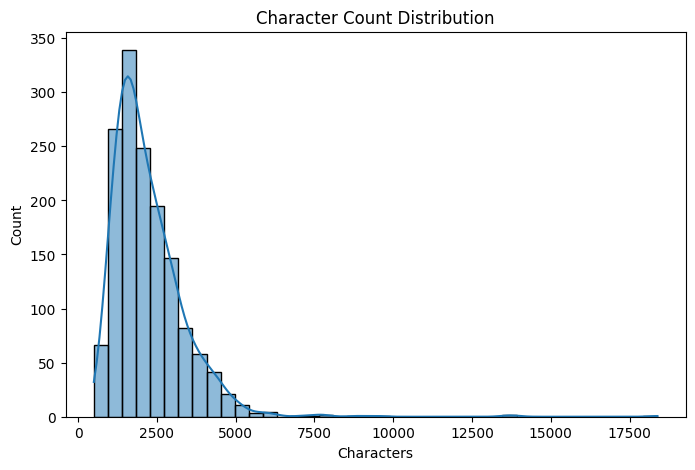

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    train_df["char_count"],
    bins=40,
    kde=True
)

plt.title("Character Count Distribution")
plt.xlabel("Characters")
plt.show()

In [17]:
train_df["word_count"] = train_df["Text"].astype(str).apply(
    lambda x: len(x.split())
)

train_df["word_count"].describe()

,word_count
count,1490.000000
mean,385.012752
std,210.898616
min,90.000000
25%,253.000000
50%,337.000000
75%,468.750000
max,3345.000000


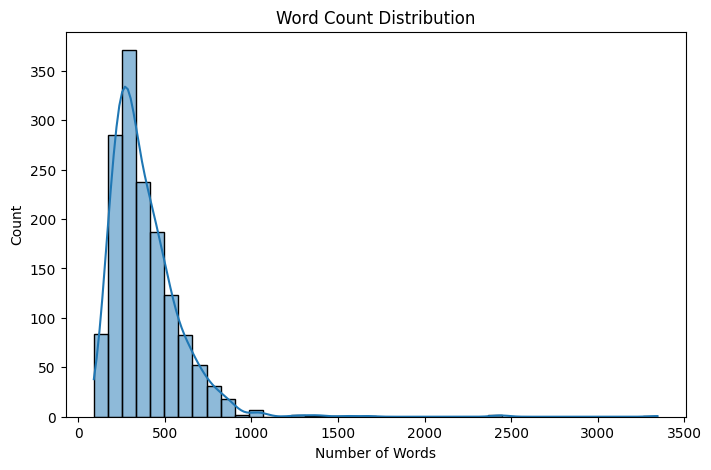

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(
    train_df["word_count"],
    bins=40,
    kde=True
)

plt.title("Word Count Distribution")
plt.xlabel("Number of Words")
plt.show()

In [25]:
#Frequency of words (before pre-processing)
from collections import Counter

all_words = " ".join(train_df["Text"].astype(str)).lower().split()
word_freq = Counter(all_words)
freq_df = pd.DataFrame(
    word_freq.most_common(20),
    columns=["Word","Frequency"]
)
freq_df.head(10)

,Word,Frequency
0,the,34992
1,to,16568
2,of,12970
3,and,12366
4,a,12102
5,in,11696
6,s,5899
7,for,5773
8,is,5478
9,that,5207


In [117]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = str(text).lower()

    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    tokens = word_tokenize(text)

    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
        and word.isalpha()
    ]

    return " ".join(tokens)

In [35]:
#Most frequent-words after cleaning
train_df["clean_text"] = train_df["Text"].apply(clean_text)

clean_words = " ".join(
    train_df["clean_text"]
).split()

clean_freq = Counter(clean_words)

clean_freq_df = pd.DataFrame(
    clean_freq.most_common(20),
    columns=["Word","Frequency"]
)

clean_freq_df.head(20)

,Word,Frequency
0,said,4838
1,mr,2006
2,year,1853
3,would,1711
4,also,1426
5,new,1334
6,people,1323
7,u,1227
8,one,1190
9,could,1032


In [36]:
train_df[["Text", "clean_text"]].head()

,Text,clean_text
0,worldcom ex-boss launches defence lawyers defe...,worldcom exboss launch defence lawyer defendin...
1,german business confidence slides german busin...,german business confidence slide german busine...
2,bbc poll indicates economic gloom citizens in ...,bbc poll indicates economic gloom citizen majo...
3,lifestyle governs mobile choice faster bett...,lifestyle governs mobile choice faster better ...
4,enron bosses in $168m payout eighteen former e...,enron boss payout eighteen former enron direct...


In [38]:
from collections import Counter

for category in train_df["Category"].unique():

    text = " ".join(
        train_df[
            train_df["Category"] == category
        ]["clean_text"]
    )

    words = text.split()
    common = Counter(words).most_common(10)
    print("\n")
    print(category)
    print(common)



business
[('said', 1100), ('year', 574), ('u', 511), ('mr', 394), ('company', 392), ('firm', 374), ('market', 340), ('would', 308), ('also', 279), ('sale', 276)]


tech
[('said', 1064), ('people', 646), ('mobile', 420), ('phone', 394), ('game', 388), ('technology', 380), ('service', 369), ('mr', 350), ('new', 349), ('also', 348)]


politics
[('said', 1445), ('mr', 1100), ('would', 710), ('labour', 488), ('government', 469), ('party', 449), ('election', 448), ('blair', 390), ('people', 372), ('minister', 371)]


sport
[('said', 635), ('game', 481), ('win', 334), ('england', 327), ('first', 323), ('player', 308), ('year', 296), ('world', 266), ('time', 262), ('last', 255)]


entertainment
[('film', 691), ('said', 594), ('best', 404), ('year', 392), ('award', 329), ('also', 277), ('show', 271), ('one', 267), ('u', 260), ('music', 255)]


In [41]:
!pip install wordcloud

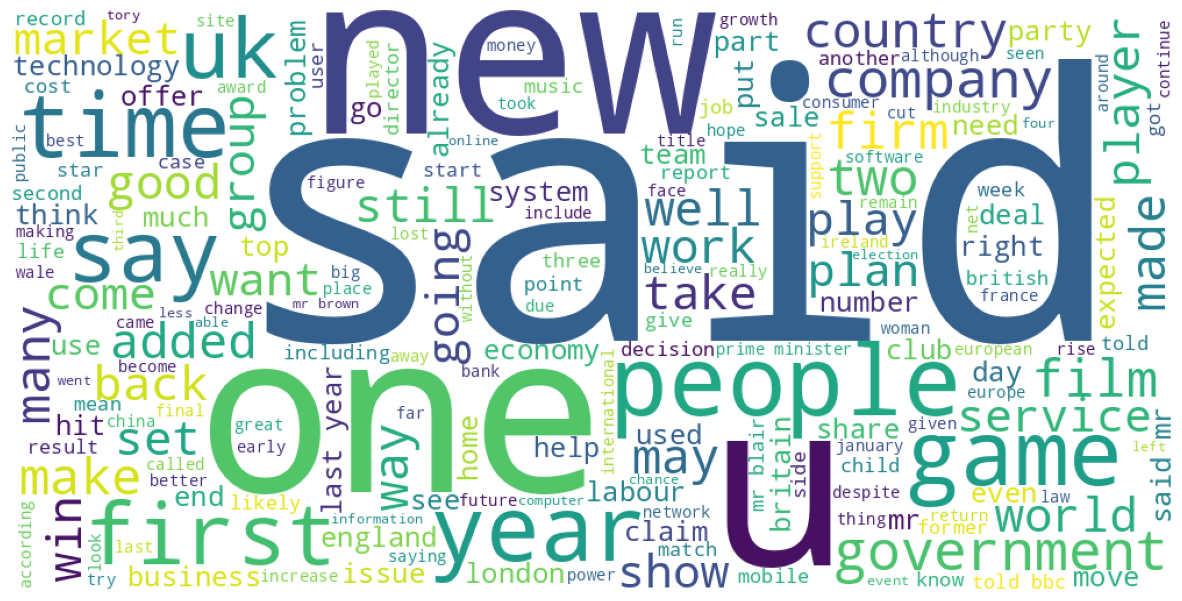

In [44]:
#Word Cloud
import wordcloud
text = " ".join(train_df["clean_text"])

wordcloud = wordcloud.WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,8))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

# Model building, training and evaluation

In [45]:

X = train_df["clean_text"]
y = train_df["Category"]

In [46]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_tfidf = vectorizer.fit_transform(X)

print(X_tfidf.shape)

(1490, 5000)


In [47]:
X_train, X_val, y_train, y_val = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [48]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC()
}

results = []

for name, model in models.items():

    print("="*60)
    print(name)

    model.fit(X_train, y_train)
    predictions = model.predict(X_val)

    accuracy = accuracy_score(y_val, predictions)

    precision = precision_score(
        y_val,
        predictions,
        average="weighted"
    )

    recall = recall_score(
        y_val,
        predictions,
        average="weighted"
    )

    f1 = f1_score(
        y_val,
        predictions,
        average="weighted"
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

Logistic Regression
Accuracy : 0.9698
Precision: 0.9703
Recall   : 0.9698
F1 Score : 0.9697
Naive Bayes
Accuracy : 0.9832
Precision: 0.9833
Recall   : 0.9832
F1 Score : 0.9832
Linear SVM
Accuracy : 0.9866
Precision: 0.9867
Recall   : 0.9866
F1 Score : 0.9865


In [49]:
comparison_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

comparison_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,Linear SVM,0.986577,0.986686,0.986577,0.986543
1,Naive Bayes,0.983221,0.983320,0.983221,0.983182
0,Logistic Regression,0.969799,0.970342,0.969799,0.969673


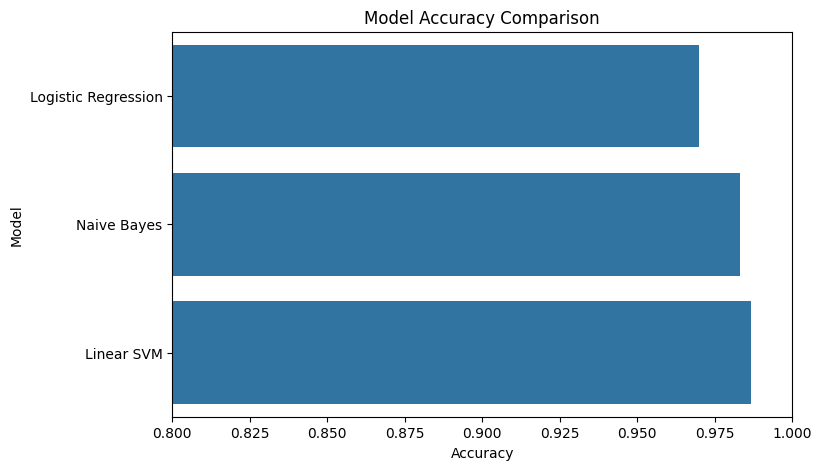

In [50]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison_df,
    x="Accuracy",
    y="Model"
)

plt.title("Model Accuracy Comparison")
plt.xlim(0.8, 1.0)

plt.show()

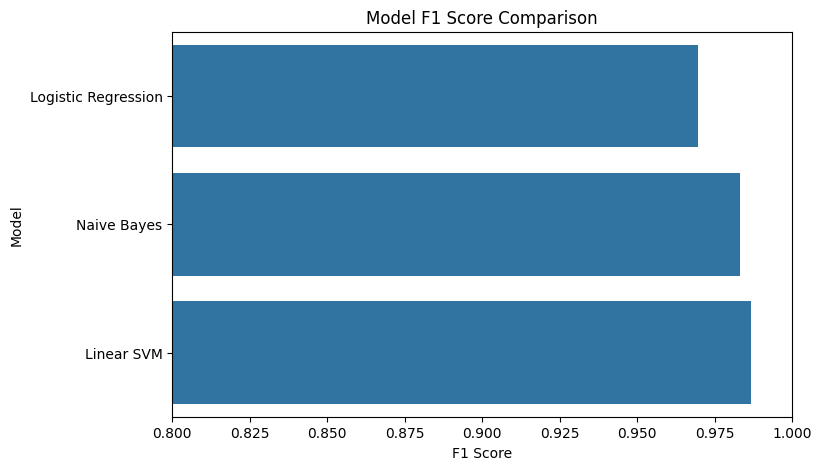

In [51]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison_df,
    x="F1 Score",
    y="Model"
)

plt.title("Model F1 Score Comparison")
plt.xlim(0.8, 1.0)

plt.show()

In [52]:
best_model = LinearSVC()
best_model.fit(X_train, y_train)
preds = best_model.predict(X_val)

print(classification_report(y_val,preds))

               precision    recall  f1-score   support

     business       0.99      1.00      0.99        67
entertainment       0.98      1.00      0.99        55
     politics       1.00      0.96      0.98        55
        sport       1.00      1.00      1.00        69
         tech       0.96      0.96      0.96        52

     accuracy                           0.99       298
    macro avg       0.99      0.99      0.99       298
 weighted avg       0.99      0.99      0.99       298



In [53]:
comparison_df.to_csv("model_comparison.csv",index=False)

Text(0.5, 1.0, 'Confusion Matrix - Linear SVM')

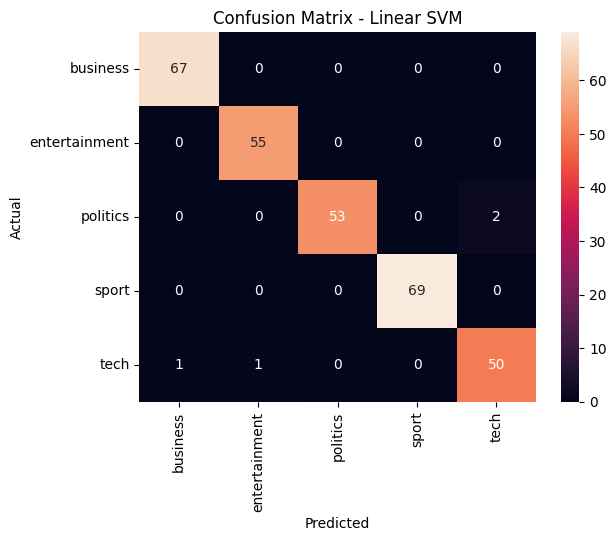

In [61]:
sns.heatmap(confusion_matrix(y_val,preds),annot=True,xticklabels=best_model.classes_,yticklabels=best_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Linear SVM")

In [62]:
svm_model = LinearSVC()

cv_scores = cross_val_score(svm_model,X_tfidf,y,cv=5,scoring="accuracy")

print("Fold Scores:")
print(cv_scores)

print("\nMean Accuracy:")
print(cv_scores.mean())

print("\nStandard Deviation:")
print(cv_scores.std())

Fold Scores:
[0.97315436 0.96308725 0.96979866 0.98322148 0.97651007]

Mean Accuracy:
0.9731543624161073

Standard Deviation:
0.006711409395973145


In [65]:
param_grid = {"C":[0.01,0.1,1,10,100]}

grid = GridSearchCV(
    LinearSVC(),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LinearSVC(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100]}, scoring='accuracy')

In [67]:
print("Best Parameters:")
print(grid.best_params_)

print("\nBest CV Score:")
print(grid.best_score_)

best_svm = grid.best_estimator_

Best Parameters:
{'C': 1}

Best CV Score:
0.9697865757181534


In [68]:
best_svm.fit(X_train, y_train)

tuned_preds = best_svm.predict(X_val)

print(classification_report(y_val,tuned_preds))

               precision    recall  f1-score   support

     business       0.99      1.00      0.99        67
entertainment       0.98      1.00      0.99        55
     politics       1.00      0.96      0.98        55
        sport       1.00      1.00      1.00        69
         tech       0.96      0.96      0.96        52

     accuracy                           0.99       298
    macro avg       0.99      0.99      0.99       298
 weighted avg       0.99      0.99      0.99       298



In [72]:
calibrated_svm = CalibratedClassifierCV(
    best_model,
    cv=5
)

calibrated_svm.fit(X_train, y_train)

CalibratedClassifierCV(cv=5, estimator=LinearSVC())

In [73]:
preds = calibrated_svm.predict(X_val)

print(classification_report(y_val, preds))

               precision    recall  f1-score   support

     business       0.99      1.00      0.99        67
entertainment       0.98      1.00      0.99        55
     politics       1.00      0.96      0.98        55
        sport       1.00      1.00      1.00        69
         tech       0.96      0.96      0.96        52

     accuracy                           0.99       298
    macro avg       0.99      0.99      0.99       298
 weighted avg       0.99      0.99      0.99       298



# Saving Model

In [74]:
joblib.dump(
    calibrated_svm,
    "calibrated_svm_news_classifier.pkl"
)

['calibrated_svm_news_classifier.pkl']

In [70]:
joblib.dump(vectorizer,"tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

# Feature importance

In [84]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [91]:
feature_names = vectorizer.get_feature_names_out()
print("No. of features:", len(feature_names))

No. of features: 5000


In [97]:
#Top words for each category

for i, category in enumerate(lr.classes_):

    print("\n")
    print(f"Category: {category}")


    top_indices = lr.coef_[i].argsort()[-15:]

    for idx in reversed(top_indices):
        print(feature_names[idx])



Category: business
firm
company
bank
market
economy
share
price
economic
profit
oil
business
growth
investment
rate
sale


Category: entertainment
film
show
music
star
album
band
singer
actor
award
song
chart
tv
festival
best
single


Category: politics
mr
party
labour
blair
election
minister
government
mp
tory
lord
would
police
secretary
child
mr blair


Category: sport
champion
match
england
player
win
cup
coach
game
chelsea
club
team
olympic
season
injury
side


Category: tech
computer
software
game
mobile
technology
user
phone
people
net
online
microsoft
service
blog
broadband
site


In [101]:
#Top words for each category with co-efficients

for i, category in enumerate(lr.classes_):

    top_indices = lr.coef_[i].argsort()[-15:]

    words = [feature_names[idx] for idx in reversed(top_indices)]
    scores = [lr.coef_[i][idx] for idx in reversed(top_indices)]

    importance_df = pd.DataFrame({
        "Word": words,
        "Coefficient": scores
    })

    print(f"\n{category}")
    display(importance_df)


business


,Word,Coefficient
0,firm,2.023236
1,company,1.788341
2,bank,1.781124
3,market,1.507280
4,economy,1.408062
5,share,1.405426
6,price,1.327476
7,economic,1.319103
8,profit,1.282241
9,oil,1.202964



entertainment


,Word,Coefficient
0,film,3.349404
1,show,1.930729
2,music,1.709358
3,star,1.701850
4,album,1.684799
5,band,1.650575
6,singer,1.547697
7,actor,1.425905
8,award,1.357197
9,song,1.284763



politics


,Word,Coefficient
0,mr,2.185285
1,party,1.976654
2,labour,1.901085
3,blair,1.739350
4,election,1.737318
5,minister,1.463169
6,government,1.455731
7,mp,1.440646
8,tory,1.335569
9,lord,1.330660



sport


,Word,Coefficient
0,champion,1.539774
1,match,1.486168
2,england,1.416014
3,player,1.355013
4,win,1.314419
5,cup,1.291129
6,coach,1.276834
7,game,1.275707
8,chelsea,1.195062
9,club,1.186008



tech


,Word,Coefficient
0,computer,1.788634
1,software,1.772012
2,game,1.751210
3,mobile,1.695985
4,technology,1.695573
5,user,1.635079
6,phone,1.387204
7,people,1.363239
8,net,1.360558
9,online,1.348906


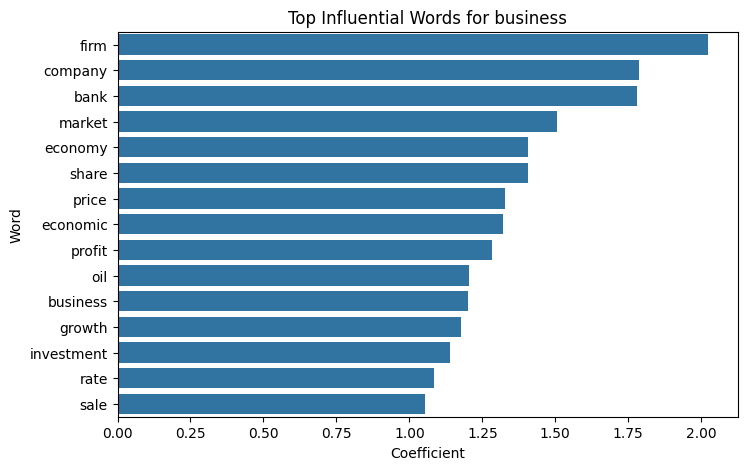

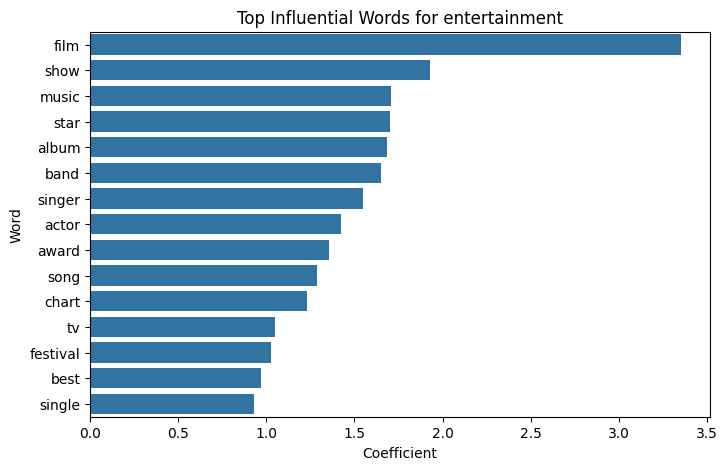

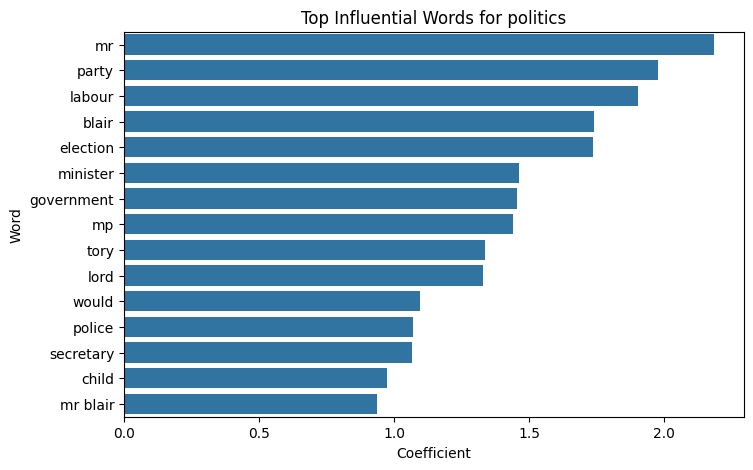

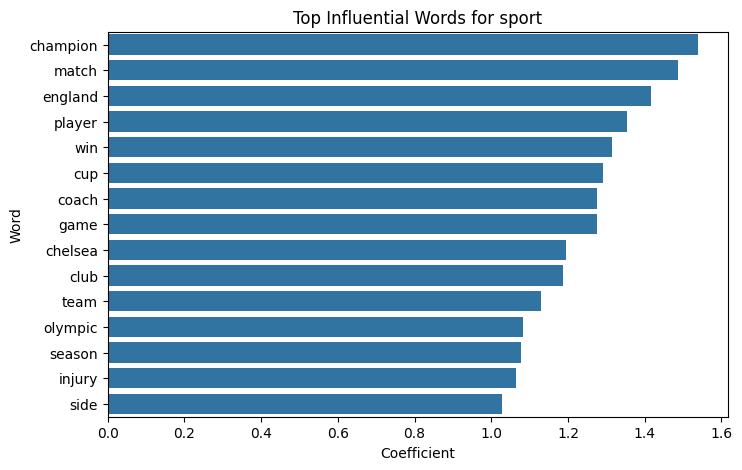

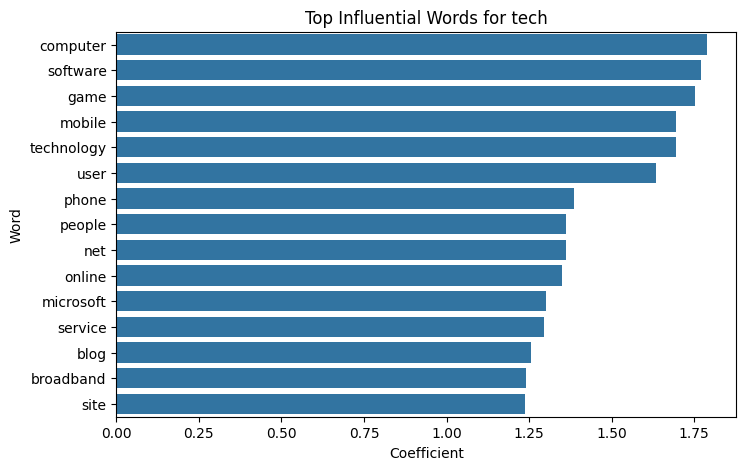

In [100]:
for i, category in enumerate(lr.classes_):

    top_indices = lr.coef_[i].argsort()[-15:]

    words = [feature_names[idx] for idx in reversed(top_indices)]
    scores = [lr.coef_[i][idx] for idx in reversed(top_indices)]

    plt.figure(figsize=(8,5))

    sns.barplot(x=scores,y=words)

    plt.title(f"Top Influential Words for {category}")
    plt.xlabel("Coefficient")
    plt.ylabel("Word")

    plt.show()

# Sentiment Analysis

In [103]:
sentiment_model = pipeline("sentiment-analysis")
#Test transformer sentiment analysis
sentiment_model("India won the match convincingly.")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[{'label': 'POSITIVE', 'score': 0.9997935891151428}]

In [104]:
def get_sentiment(text):

    result = sentiment_model(text)[0]

    sentiment = result["label"]
    confidence = result["score"]

    return sentiment, confidence

In [106]:
model = joblib.load("calibrated_svm_news_classifier.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

In [121]:
def preprocess_text(text):

    text = str(text).lower()

    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    tokens = word_tokenize(text)

    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
        and word.isalpha()
    ]

    return " ".join(tokens)

In [135]:
def analyze_news(text):

    cleaned_text = preprocess_text(text)

    vec = vectorizer.transform([cleaned_text])

    category = model.predict(vec)[0]

    probs = model.predict_proba(vec)[0]

    category_confidence = probs.max()

    sentiment, sentiment_confidence = get_sentiment(text)

    return {
        "Category": category,
        "Category Confidence":
            float(round(category_confidence * 100, 2)),

        "Sentiment": sentiment,

        "Sentiment Confidence":
            round(sentiment_confidence * 100, 2)
    }

In [136]:
sam_text = """
Apple announced a new AI-powered product and
investors responded positively.
"""

result = analyze_news(sam_text)

print(result)

{'Category': 'business', 'Category Confidence': 76.57, 'Sentiment': 'POSITIVE', 'Sentiment Confidence': 99.93}
